In [25]:
import numpy as np
import matplotlib as mpl
#mpl.use('pdf')
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# plt.rc('font', family='serif', serif='Times')
# Arial
plt.rc('font', family='Arial')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)
plt.rc('axes', labelsize=11)
#axes.linewidth : 0.5
plt.rc('axes', linewidth=0.5)
#ytick.major.width : 0.5
plt.rc('ytick.major', width=0.5)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('ytick.minor', visible=True)

# set grid under the plot
# https://stackoverflow.com/questions/23357798/how-to-draw-grid-lines-behind-matplotlib-bar-graph
# https://stackoverflow.com/questions/1726391/matplotlib-draw-grid-lines-behind-other-graph-elements/39039520#39039520
plt.rc('axes', axisbelow=True)


#plt.style.use(r"..\..\styles\infocom.mplstyle") # Insert your save location here

# width as measured in inkscape
fig_width = 3.487
fig_height = fig_width / 1.618
# fig_height = 1.8
#fig_height = fig_width / 1.3 / 2

In [2]:
import numpy as np
num_instances = 7
# file_list = list(range(num_cases))
# filename_prefix = "results/results_japan_averaged_rate"
# folder_prefix = "results/TS8Module10-0708/"
# folder_prefix = "results/TS8Module10-0711/"
folder_prefix = "results/TS8Module10-0717-1Ins/"
acceptance_ratio = np.zeros((4, num_instances), dtype=float)
stored_keys = np.zeros((4, num_instances), dtype=float)
num_physical_hops = np.zeros((4, num_instances), dtype=float)
num_virtual_hops = np.zeros((4, num_instances), float)
num_qkd_module = np.zeros((4, num_instances), dtype=float)

case_prefix_list = ["results_No_OB_TR_german_averaged_rate", "results_OB_german_averaged_rate", 
         "results_TR_german_averaged_rate", "results_OB_TR_german_averaged_rate"]

In [3]:
for j in range(num_instances):
    #for file in file_list:
#     file = file_list[j]
    for i in range(len(case_prefix_list)):
        case_prefix = case_prefix_list[i]
        filename = folder_prefix + case_prefix + str(j) + "_1.txt"
        with open(filename, "r") as f:
            lines = f.readlines()
            tmp = 100 * float(lines[0].split(" ")[0])
            acceptance_ratio[i][j] = tmp
            stored_keys[i][j] = float(lines[1].split(" ")[0])
            num_qkd_module[i][j] = float(lines[1].split(" ")[1])
            num_physical_hops[i][j] = float(lines[1].split(" ")[2])
            num_virtual_hops[i][j] = float(lines[1].split(" ")[3])
            
print(acceptance_ratio)
print(num_qkd_module)

[[ 20.37037037  20.37037037  20.37037037  20.37037037  20.37037037
   20.37037037  20.37037037]
 [ 85.18518519  78.7037037   73.14814815  67.59259259  62.96296296
   58.33333333  52.77777778]
 [ 96.2962963   79.62962963  78.7037037   58.33333333  52.77777778
   57.40740741  43.51851852]
 [100.          93.51851852  86.11111111  80.55555556  75.
   69.44444444  64.81481481]]
[[1.33333333 1.5        1.5        1.6        1.66666667 1.66666667
  1.71428571]
 [1.43834541 1.56980392 1.61897227 1.66138291 1.71168831 1.72747887
  1.75834351]
 [2.94615385 3.06760797 3.06705882 3.47120181 3.11267943 3.04789834
  3.74099275]
 [1.96759259 2.03663366 2.2218638  2.32545156 2.25122477 2.2791746
  2.21595238]]


In [4]:
dataMatrix = acceptance_ratio
print(dataMatrix)

[[ 20.37037037  20.37037037  20.37037037  20.37037037  20.37037037
   20.37037037  20.37037037]
 [ 85.18518519  78.7037037   73.14814815  67.59259259  62.96296296
   58.33333333  52.77777778]
 [ 96.2962963   79.62962963  78.7037037   58.33333333  52.77777778
   57.40740741  43.51851852]
 [100.          93.51851852  86.11111111  80.55555556  75.
   69.44444444  64.81481481]]


[0 1 2 3 4 5 6]
['3', '6', '9', '12', '15', '18', '21']


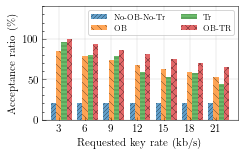

In [5]:
N = 7
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Acceptance ratio (\%)')
ax1.set_xlabel('Requested key rate (kb/s)')
ax1.set_ylim(0, 140)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.17, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/acceptance-ratio.pdf')
fig.savefig('plot/acceptance-ratio.png')

In [6]:
np.arange(3, 24, 3)

array([ 3,  6,  9, 12, 15, 18, 21])

[0 1 2 3 4 5 6]
AxesSubplot(0.125,0.125;0.775x0.755)


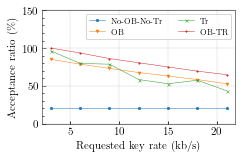

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=1)
stage = np.arange(7)

print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
x_tick_label_list = [float(elem) for elem in x_tick_label_list]

for i in range(4):
    ax.plot(x_tick_label_list, dataMatrix[i][stage], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
    
ax.set_ylabel('Acceptance ratio (\%)')
ax.set_xlabel('Requested key rate (kb/s)')
ax.set_ylim(0, 150)

ax.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})

# ax[0,0].legend(loc='upper center', bbox_to_anchor=(1.15, 1.3),
#           ncol=5, prop={'size': 5}, handletextpad=0.2)

fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax.grid(lw = 0.25, clip_on=False)
fig.savefig('plot/acceptance-ratio.pdf')
fig.savefig('plot/acceptance-ratio.png')

In [8]:
dataMatrix = num_qkd_module
print(dataMatrix)

[[1.33333333 1.5        1.5        1.6        1.66666667 1.66666667
  1.71428571]
 [1.43834541 1.56980392 1.61897227 1.66138291 1.71168831 1.72747887
  1.75834351]
 [2.94615385 3.06760797 3.06705882 3.47120181 3.11267943 3.04789834
  3.74099275]
 [1.96759259 2.03663366 2.2218638  2.32545156 2.25122477 2.2791746
  2.21595238]]


In [9]:
dataMatrix = stored_keys
print(dataMatrix)

[[1518.25       1471.375      1427.375      1380.5        1333.625
  1289.625      1242.75      ]
 [1046.34099328  882.42590306  727.92002564  708.56681223  655.74277942
   609.05928642  668.8469567 ]
 [ 342.375       206.125       249.375       137.625       216.
   142.125        12.125     ]
 [ 357.63751485  264.32400351  131.04608131   46.17866511    5.19100437
    11.7710411   -27.6937461 ]]


[0 1 2 3 4 5 6]
['3', '6', '9', '12', '15', '18', '21']


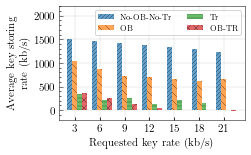

In [10]:
N = 7
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average key storing \n rate (kb/s)')
ax1.set_xlabel('Requested key rate (kb/s)')
ax1.set_ylim(-200, 2200)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.21, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/key-storing-rate.pdf')
fig.savefig('plot/key-storing-rate.png')

[0 1 2 3 4 5 6]
AxesSubplot(0.125,0.125;0.775x0.755)


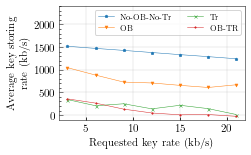

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1)
stage = np.arange(7)

print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
x_tick_label_list = [float(elem) for elem in x_tick_label_list]

for i in range(4):
    ax.plot(x_tick_label_list, dataMatrix[i][stage], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
    
ax.set_ylabel('Average key storing \n rate (kb/s)')
ax.set_xlabel('Requested key rate (kb/s)')
ax.set_ylim(-100, 2400)

ax.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})

# ax[0,0].legend(loc='upper center', bbox_to_anchor=(1.15, 1.3),
#           ncol=5, prop={'size': 5}, handletextpad=0.2)

fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.21, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax.grid(lw = 0.25, clip_on=False)
fig.savefig('plot/key-storing-rate.pdf')
fig.savefig('plot/key-storing-rate.png')

In [12]:
dataMatrix = num_qkd_module
print(dataMatrix)

[[1.33333333 1.5        1.5        1.6        1.66666667 1.66666667
  1.71428571]
 [1.43834541 1.56980392 1.61897227 1.66138291 1.71168831 1.72747887
  1.75834351]
 [2.94615385 3.06760797 3.06705882 3.47120181 3.11267943 3.04789834
  3.74099275]
 [1.96759259 2.03663366 2.2218638  2.32545156 2.25122477 2.2791746
  2.21595238]]


[0 1 2 3 4 5 6]
['3', '6', '9', '12', '15', '18', '21']


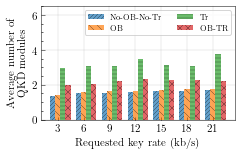

In [13]:
N = 7
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n QKD modules')
ax1.set_xlabel('Requested key rate (kb/s)')
ax1.set_ylim(0, 6.5)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/num-qkd-modules.pdf')
fig.savefig('plot/num-qkd-modules.png')

[0 1 2 3 4 5 6]
AxesSubplot(0.125,0.125;0.775x0.755)


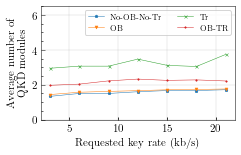

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=1)
stage = np.arange(7)

print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
x_tick_label_list = [float(elem) for elem in x_tick_label_list]

for i in range(4):
    ax.plot(x_tick_label_list, dataMatrix[i][stage], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
    
ax.set_ylabel('Average number of \n QKD modules')
ax.set_xlabel('Requested key rate (kb/s)')
ax.set_ylim(0, 6.5)

ax.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})

# ax[0,0].legend(loc='upper center', bbox_to_anchor=(1.15, 1.3),
#           ncol=5, prop={'size': 5}, handletextpad=0.2)

fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax.grid(lw = 0.25, clip_on=False)
fig.savefig('plot/num-qkd-modules.pdf')
fig.savefig('plot/num-qkd-modules.png')

In [15]:
dataMatrix = num_physical_hops
print(dataMatrix)

[[0.66666667 0.75       0.75       0.8        0.83333333 0.83333333
  0.85714286]
 [0.71917271 0.78490196 0.80948614 0.83069145 0.85584416 0.86373944
  0.87917175]
 [1.36410256 1.3732835  1.43117647 1.56334089 1.4994266  1.43736908
  1.72624612]
 [0.92515432 0.95148515 1.03369176 1.07920088 1.0547962  1.0565873
  1.03442177]]


[0 1 2 3 4 5 6]
['3', '6', '9', '12', '15', '18', '21']


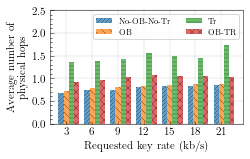

In [16]:
N = 7
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n physical hops')
ax1.set_xlabel('Requested key rate (kb/s)')
ax1.set_ylim(0, 2.5)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/num-physical-hops.pdf')
fig.savefig('plot/num-physical-hops.png')

[0 1 2 3 4 5 6]
AxesSubplot(0.125,0.125;0.775x0.755)


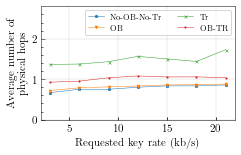

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1)
stage = np.arange(7)

print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
x_tick_label_list = [float(elem) for elem in x_tick_label_list]

for i in range(4):
    ax.plot(x_tick_label_list, dataMatrix[i][stage], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
    
ax.set_ylabel('Average number of \n physical hops')
ax.set_xlabel('Requested key rate (kb/s)')
ax.set_ylim(0, 2.8)

ax.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})

# ax[0,0].legend(loc='upper center', bbox_to_anchor=(1.15, 1.3),
#           ncol=5, prop={'size': 5}, handletextpad=0.2)

fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax.grid(lw = 0.25, clip_on=False)
fig.savefig('plot/num-physical-hops.pdf')
fig.savefig('plot/num-physical-hops.png')

In [18]:
dataMatrix = num_virtual_hops
print(dataMatrix)

[[0.33333333 0.25       0.25       0.2        0.16666667 0.16666667
  0.14285714]
 [0.28082729 0.21509804 0.19051386 0.16930855 0.14415584 0.13626056
  0.12082825]
 [1.56907051 1.38629568 0.65852941 1.01751071 0.72112858 0.4661011
  0.75612048]
 [0.68595679 0.72277228 0.61433692 0.55145047 0.58007545 0.4715873
  0.47387188]]


[0 1 2 3 4 5 6]
['3', '6', '9', '12', '15', '18', '21']


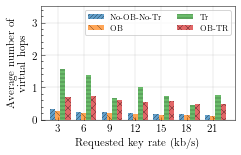

In [19]:
N = 7
ind = np.arange(N) 
width = 1 / 5

# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n virtual hops')
ax1.set_xlabel('Requested key rate (kb/s)')
ax1.set_ylim(0, 3.5)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/num-virtual-hops.pdf')
fig.savefig('plot/num-virtual-hops.png')

[0 1 2 3 4 5 6]
AxesSubplot(0.125,0.125;0.775x0.755)


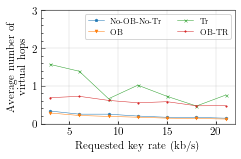

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=1)
stage = np.arange(7)

print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
x_tick_label_list = [float(elem) for elem in x_tick_label_list]

for i in range(4):
    ax.plot(x_tick_label_list, dataMatrix[i][stage], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
    
ax.set_ylabel('Average number of \n virtual hops')
ax.set_xlabel('Requested key rate (kb/s)')
ax.set_ylim(0, 3)

ax.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})

# ax[0,0].legend(loc='upper center', bbox_to_anchor=(1.15, 1.3),
#           ncol=5, prop={'size': 5}, handletextpad=0.2)

fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax.grid(lw = 0.25, clip_on=False)
fig.savefig('plot/num-virtual-hops.pdf')
fig.savefig('plot/num-virtual-hops.png')

In [40]:
import numpy as np
import matplotlib as mpl
#mpl.use('pdf')
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# plt.rc('font', family='serif', serif='Times')
# Arial
plt.rc('font', family='Arial')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=6)
plt.rc('ytick', labelsize=6)
plt.rc('axes', labelsize=6)
#axes.linewidth : 0.5
plt.rc('axes', linewidth=0.5)
#ytick.major.width : 0.5
plt.rc('ytick.major', width=0.5)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('ytick.minor', visible=True)

# set grid under the plot
# https://stackoverflow.com/questions/23357798/how-to-draw-grid-lines-behind-matplotlib-bar-graph
# https://stackoverflow.com/questions/1726391/matplotlib-draw-grid-lines-behind-other-graph-elements/39039520#39039520
plt.rc('axes', axisbelow=True)


#plt.style.use(r"..\..\styles\infocom.mplstyle") # Insert your save location here

# width as measured in inkscape
fig_width = 3.487
fig_height = fig_width / 1.618
# fig_height = 1.8
#fig_height = fig_width / 1.3 / 2

[0 1 2 3 4 5 6]
[<AxesSubplot:> <AxesSubplot:> <AxesSubplot:> <AxesSubplot:>]


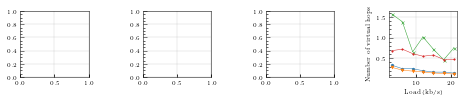

In [41]:
fig, ax = plt.subplots(nrows=1, ncols=4)


stage = np.arange(7)

print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

x_tick_label_list = ['3', '6', '9', '12', '15', '18', '21']
x_tick_label_list = [float(elem) for elem in x_tick_label_list]

for i in range(4):
    ax[3].plot(x_tick_label_list, dataMatrix[i][stage], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
ax[3].set_ylabel('Number of virtual hops')
ax[3].set_xlabel('Load (kb/s)')
    
mpl.pyplot.subplots_adjust(wspace = 0.8, hspace=0.5)
fig.subplots_adjust(left=.10, bottom=.10, right=.97, top=.949)
    
for i in range(0, 4):
    ax[i].grid(lw = 0.25)
#     ax[i].xaxis.set_major_locator(MaxNLocator(integer=True))

fig.set_size_inches(fig_width*2, fig_height/2)
plt.show()
fig.savefig('plot/@load-allfigs.png')
fig.savefig('plot/@load-allfigs.pdf')
# fig.savefig('heuristic-utilization-CC.pdf')

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=2)
stage = np.arange(21)
stage_small = np.arange(11)
stage_medium = np.arange(16)
stage_large = np.arange(21)
print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['Fix-em', 'Link-rem', 'Flex-rem(5, 0)', 'Flex-rem(5, 2)', 'Any-rem']

for i in range(5):
    ax[0,0].plot(stage_small, small_node_data[i][stage_small], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
for i in range(5):
    ax[0,1].plot(stage_small, small_link_data[i][stage_small], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])

for i in range(5):
    ax[1,0].plot(stage_medium, medium_node_data[i][stage_medium], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
for i in range(5):
    ax[1,1].plot(stage_medium, medium_link_data[i][stage_medium], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
for i in range(5):
    ax[2,0].plot(stage_large, large_node_data[i][stage_large], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    
for i in range(5):
    ax[2,1].plot(stage_large, large_link_data[i][stage_large], linewidth=0.5,
                 marker=marker_list[i], markersize=3, markeredgewidth=0.5,
                 label=label_list[i])
    

for i in range(0, 2):
    ax[0, i].set_xlabel('Stages')
for i in range(0, 2):
    ax[1, i].set_xlabel('Stages')
for i in range(0, 2):
    ax[2, i].set_xlabel('Stages')

for i in range(0, 3):
    ax[i,0].set_ylabel("Recovered node capacity")
for i in range(0, 3):
    ax[i,1].set_ylabel("Recovered link capacity")
#for i in range(0, 3):

ax[0,0].legend(loc='upper center', bbox_to_anchor=(1.15, 1.26),
          ncol=5, prop={'size': 5}, handletextpad=0.2)


ax[0,0].yaxis.set_label_coords(-0.16, 0.5)
ax[0,1].yaxis.set_label_coords(-0.16, 0.5)

for i in range(1, 3):
    for j in range(0, 2):
        ax[i,j].yaxis.set_label_coords(-0.164, 0.5)
for i in range(0, 3):
    for j in range(0, 2):
        ax[i,j].xaxis.set_label_coords(0.5, -0.17)
#x1.yaxis.set_label_coords(-0.17,0.5)
ax[0, 0].set_title('(a) 20\% substrate failures', y=-0.47, fontsize=7)
ax[0, 1].set_title('(b) 20\% substrate failures', y=-0.47, fontsize=7)
ax[1, 0].set_title('(c) 30\% substrate failures', y=-0.47, fontsize=7)
ax[1, 1].set_title('(d) 30\% substrate failures', y=-0.47, fontsize=7)
ax[2, 0].set_title('(e) 40\% substrate failures', y=-0.47, fontsize=7)
ax[2, 1].set_title('(f) 40\% substrate failures', y=-0.47, fontsize=7)

mpl.pyplot.subplots_adjust(wspace = 0.3, hspace=0.5)
fig.subplots_adjust(left=.10, bottom=.10, right=.97, top=.949)


for i in range(0, 3):
    for j in range(0, 2):
        ax[i, j].grid(lw = 0.25)
        ax[i,j].xaxis.set_major_locator(MaxNLocator(integer=True))
        
plt.show()